<a href="https://colab.research.google.com/github/abilashkannanv/AIML/blob/main/TrustCart_Phase2_Fake_Review_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the reviews.csv dataset
reviews_df = pd.read_csv('/content/sample_data/reviews.csv')

### Data Inspection
Let's inspect the first few rows, the data types, and descriptive statistics of the dataset.

In [2]:
# Display the first 5 rows of the DataFrame
display(reviews_df.head())

,review_text,seller_id,review_type
0,Once enjoying my crisp cool water. Our orders ...,4,genuine
1,This should say it all: we found a dress we lo...,1,genuine
2,Slow service\nBelow average food \nIll pass,2,genuine
3,I hit the Primanti Brothers Market Square loca...,3,genuine
4,An impressive and thoughtfully designed produc...,5,fake_generated


In [3]:
# Get a concise summary of the DataFrame, including data types and non-null values
display(reviews_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_text  6000 non-null   object
 1   seller_id    6000 non-null   int64 
 2   review_type  6000 non-null   object
dtypes: int64(1), object(2)
memory usage: 140.8+ KB


None

In [4]:
# Generate descriptive statistics of the DataFrame
display(reviews_df.describe(include='all'))

,review_text,seller_id,review_type
count,6000,6000.000000,6000
unique,4019,NaN,3
top,This product delivers an exceptional experienc...,NaN,genuine
freq,266,NaN,4000
mean,NaN,3.486500,NaN
std,NaN,1.362153,NaN
min,NaN,1.000000,NaN
25%,NaN,2.000000,NaN
50%,NaN,4.000000,NaN
75%,NaN,5.000000,NaN


### Target Variable Conversion and Identification
Let's examine the unique values in the `review_type` column to understand how to convert it into a binary target variable.

In [5]:
# Display unique values in 'review_type'
print("Unique values in 'review_type':")
display(reviews_df['review_type'].unique())

Unique values in 'review_type':


array(['genuine', 'fake_generated', 'fake_templated'], dtype=object)

In [6]:
# Convert 'review_type' into a binary target variable
# We'll map 'genuine' to 1 and 'fake_generated' / 'paraphrased' to 0.
reviews_df['is_genuine'] = reviews_df['review_type'].apply(lambda x: 1 if x == 'genuine' else 0)

print("Value counts for the new binary target variable 'is_genuine':")
display(reviews_df['is_genuine'].value_counts())

# Display the first few rows with the new target variable
print("First 5 rows with the new 'is_genuine' column:")
display(reviews_df.head())

Value counts for the new binary target variable 'is_genuine':


,count
is_genuine,
1,4000
0,2000


First 5 rows with the new 'is_genuine' column:


,review_text,seller_id,review_type,is_genuine
0,Once enjoying my crisp cool water. Our orders ...,4,genuine,1
1,This should say it all: we found a dress we lo...,1,genuine,1
2,Slow service\nBelow average food \nIll pass,2,genuine,1
3,I hit the Primanti Brothers Market Square loca...,3,genuine,1
4,An impressive and thoughtfully designed produc...,5,fake_generated,0


### Input Features and Target Label Identification

Based on the problem statement and the data at hand:

*   **Input Features (X):** `review_text` and `seller_id`.
*   **Target Label (y):** `is_genuine` (the newly created binary variable).

In [7]:
# Explicitly define input features and target label
X = reviews_df[['review_text', 'seller_id']]
y = reviews_df['is_genuine']

print("Identified Input Features (X):")
display(X.head())

print("Identified Target Label (y):")
display(y.head())

Identified Input Features (X):


,review_text,seller_id
0,Once enjoying my crisp cool water. Our orders ...,4
1,This should say it all: we found a dress we lo...,1
2,Slow service\nBelow average food \nIll pass,2
3,I hit the Primanti Brothers Market Square loca...,3
4,An impressive and thoughtfully designed produc...,5


Identified Target Label (y):


,is_genuine
0,1
1,1
2,1
3,1
4,0


### Task 2: Text Preprocessing

Now, let's clean the `review_text` data by applying several preprocessing steps.

In [8]:
# 1. Convert text to lowercase
reviews_df['cleaned_review_text'] = reviews_df['review_text'].str.lower()
print("Reviews after converting to lowercase:")
display(reviews_df[['review_text', 'cleaned_review_text']].head())

Reviews after converting to lowercase:


,review_text,cleaned_review_text
0,Once enjoying my crisp cool water. Our orders ...,once enjoying my crisp cool water. our orders ...
1,This should say it all: we found a dress we lo...,this should say it all: we found a dress we lo...
2,Slow service\nBelow average food \nIll pass,slow service\nbelow average food \nill pass
3,I hit the Primanti Brothers Market Square loca...,i hit the primanti brothers market square loca...
4,An impressive and thoughtfully designed produc...,an impressive and thoughtfully designed produc...


In [9]:
import re
import string

# 2. Remove punctuation, numbers, and special characters
def remove_punc_num_special(text):
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text) # Remove punctuation
    text = re.sub(r'\d+', '', text) # Remove numbers
    text = re.sub(r'[^\w\s]', '', text) # Remove special characters (keep alphanumeric and whitespace)
    return text

reviews_df['cleaned_review_text'] = reviews_df['cleaned_review_text'].apply(remove_punc_num_special)
print("Reviews after removing punctuation, numbers, and special characters:")
display(reviews_df[['review_text', 'cleaned_review_text']].head())

Reviews after removing punctuation, numbers, and special characters:


,review_text,cleaned_review_text
0,Once enjoying my crisp cool water. Our orders ...,once enjoying my crisp cool water our orders w...
1,This should say it all: we found a dress we lo...,this should say it all we found a dress we lov...
2,Slow service\nBelow average food \nIll pass,slow servicenbelow average food nill pass
3,I hit the Primanti Brothers Market Square loca...,i hit the primanti brothers market square loca...
4,An impressive and thoughtfully designed produc...,an impressive and thoughtfully designed produc...


In [10]:
# 3. Normalize whitespace
def normalize_whitespace(text):
    return re.sub(r'\s+', ' ', text).strip()

reviews_df['cleaned_review_text'] = reviews_df['cleaned_review_text'].apply(normalize_whitespace)
print("Reviews after normalizing whitespace:")
display(reviews_df[['review_text', 'cleaned_review_text']].head())

Reviews after normalizing whitespace:


,review_text,cleaned_review_text
0,Once enjoying my crisp cool water. Our orders ...,once enjoying my crisp cool water our orders w...
1,This should say it all: we found a dress we lo...,this should say it all we found a dress we lov...
2,Slow service\nBelow average food \nIll pass,slow servicenbelow average food nill pass
3,I hit the Primanti Brothers Market Square loca...,i hit the primanti brothers market square loca...
4,An impressive and thoughtfully designed produc...,an impressive and thoughtfully designed produc...


### Cleaned Text for Tokenization

The `cleaned_review_text` column now contains the preprocessed text, ready for further steps like tokenization and feature extraction.

In [12]:
# Update the input features (X) with the cleaned text
# To avoid SettingWithCopyWarning, we re-initialize X using the cleaned_review_text
X = reviews_df[['cleaned_review_text', 'seller_id']].copy()

print("Updated Input Features (X) with cleaned review text:")
display(X.head())

Updated Input Features (X) with cleaned review text:


,cleaned_review_text,seller_id
0,once enjoying my crisp cool water our orders w...,4
1,this should say it all we found a dress we lov...,1
2,slow servicenbelow average food nill pass,2
3,i hit the primanti brothers market square loca...,3
4,an impressive and thoughtfully designed produc...,5


### Task 3: Tokenization and Padding

Now we will tokenize the cleaned review text, convert it into numerical sequences, and apply padding.

In [13]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Initialize the Tokenizer
# num_words: the maximum number of words to keep, based on word frequency.
#             Only the most common num_words-1 words will be kept.
# oov_token: a token to replace out-of-vocabulary words during text_to_sequence calls.
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")

# Fit the tokenizer on the cleaned review text
# This builds the word index
tokenizer.fit_on_texts(X['cleaned_review_text'])

print("Tokenizer fitted. Vocabulary size:", len(tokenizer.word_index))
# Display the first 10 word-index mappings
print("\nFirst 10 word-index mappings:")
for word, index in list(tokenizer.word_index.items())[:10]:
    print(f"  {word}: {index}")

Tokenizer fitted. Vocabulary size: 23944

First 10 word-index mappings:
  <OOV>: 1
  the: 2
  and: 3
  a: 4
  i: 5
  to: 6
  was: 7
  of: 8
  it: 9
  in: 10


In [14]:
# Convert text into numerical sequences
sequences = tokenizer.texts_to_sequences(X['cleaned_review_text'])

print("\nOriginal text of first review:\n", X['cleaned_review_text'].iloc[0])
print("\nNumerical sequence of first review:\n", sequences[0])

# Determine the maximum sequence length
max_sequence_len = max(len(s) for s in sequences)
print(f"\nMaximum sequence length: {max_sequence_len}")


Original text of first review:
 once enjoying my crisp cool water our orders were taken promptly i ordered the chicken club and customized it with a side of coleslaw my better half had the fish sandwich with a coleslaw as well the food came like the wind the coleslaw was damn good the best our sandwiches couldnt have been better if jesus himself made them all around it was the bees knees

Numerical sequence of first review:
 [320, 1906, 16, 1344, 551, 441, 50, 645, 26, 722, 1754, 5, 92, 2, 153, 1253, 3, 7785, 9, 14, 4, 235, 8, 804, 16, 111, 342, 24, 2, 232, 156, 14, 4, 804, 33, 106, 2, 31, 121, 39, 2, 4771, 2, 804, 7, 1156, 28, 2, 78, 50, 412, 430, 22, 54, 111, 40, 5408, 2021, 146, 90, 37, 166, 9, 7, 2, 5409, 4318]

Maximum sequence length: 932


In [15]:
# Apply padding to ensure uniform input length for the model
# We'll pad to the maximum sequence length found, or a reasonable fixed length if it's too long.
# For this dataset, let's use the max_sequence_len directly.
padded_sequences = pad_sequences(sequences, maxlen=max_sequence_len, padding='post', truncating='post')

print("\nShape of padded sequences:", padded_sequences.shape)
print("\nPadded sequence of first review (first 20 elements):\n", padded_sequences[0][:20])

# Update X with the padded sequences
X_padded = padded_sequences

print("\n'X_padded' is ready for model input.")


Shape of padded sequences: (6000, 932)

Padded sequence of first review (first 20 elements):
 [ 320 1906   16 1344  551  441   50  645   26  722 1754    5   92    2
  153 1253    3 7785    9   14]

'X_padded' is ready for model input.


### Task 4: Dataset Splitting

We will now split the dataset into training and testing sets, ensuring that reviews from the same seller do not appear in both sets to prevent data leakage. This is achieved using group-based splitting.

In [30]:
from sklearn.model_selection import GroupShuffleSplit

# Define the groups (seller_id) for group-based splitting
groups = reviews_df['seller_id']

# Initialize GroupShuffleSplit with a new random_state to try and get a more balanced test set
# Let's try 24 for random_state
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=24) # Changed random_state

# Get the train and test indices
for train_idx, test_idx in gss.split(X_padded, y, groups):
    X_train, X_test = X_padded[train_idx], X_padded[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Verify that no seller_id appears in both train and test sets
common_sellers = set(groups_train.unique()) & set(groups_test.unique())
print(f"\nCommon seller_ids between train and test sets: {len(common_sellers)}")
if len(common_sellers) == 0:
    print("Successfully ensured no seller_id appears in both train and test sets.")
else:
    print(f"Warning: {len(common_sellers)} seller_ids found in both sets.")

print("\nDistribution of y_test (new split):")
display(y_test.value_counts())

Shape of X_train: (4235, 932)
Shape of X_test: (1765, 932)
Shape of y_train: (4235,)
Shape of y_test: (1765,)

Common seller_ids between train and test sets: 0
Successfully ensured no seller_id appears in both train and test sets.

Distribution of y_test (new split):


,count
is_genuine,
0,1031
1,734


### Explanation of Data Leakage Prevention

**Why is leakage prevention critical in real-world ML systems?**

Data leakage occurs when information from the test dataset 'leaks' into the training dataset. This can happen in various ways, such as:

1.  **Target leakage:** When features that are highly correlated with the target variable, and would not be available at prediction time, are used during training.
2.  **Train-test contamination:** When information from the test set is used (directly or indirectly) to create features or models for the training set.

In this specific task, if we didn't use group-based splitting and allowed reviews from the same `seller_id` to appear in both the training and testing sets, the model could inadvertently learn seller-specific patterns. When evaluated on the test set, it would appear to perform better than it would on truly unseen data from new sellers, because it has already 'seen' some data points from those sellers during training. This would lead to an **overoptimistic evaluation of the model's performance**.

**Criticality in real-world ML systems:**

*   **Misleading Performance Metrics:** Data leakage can lead to highly inflated performance metrics (e.g., accuracy, precision, recall) on the test set, making us believe the model is more robust and accurate than it truly is.
*   **Poor Generalization:** A model trained with data leakage will fail to generalize well to new, unseen data in production environments, leading to poor real-world performance and potentially significant business consequences.
*   **Loss of Trust:** Deploying a model that performs poorly in production after showing excellent results during development can lead to a loss of trust in the ML system and the team behind it.
*   **Incorrect Business Decisions:** Decisions based on a model's misleading performance can be flawed, leading to wasted resources, missed opportunities, or negative impacts.

By using `GroupShuffleSplit` with `seller_id` as the grouping variable, we ensure that the model is evaluated on reviews from sellers it has never encountered during training. This provides a more realistic and reliable estimate of the model's ability to generalize to new, unseen sellers, which is crucial for building robust and trustworthy ML systems.

### Task 5: Build and Compile the Deep Learning Model

Now, let's build a deep learning model using TensorFlow/Keras with the following architecture:

1.  **Embedding Layer:** To convert our integer-encoded words into dense vectors of fixed size.
2.  **LSTM Layer:** A type of recurrent neural network capable of learning order dependence in sequence prediction problems.
3.  **Dense Output Layer:** A fully connected layer with a sigmoid activation function for binary classification.

In [17]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Model parameters
vocabulary_size = len(tokenizer.word_index) + 1  # +1 for padding index 0
embedding_dim = 128
lstm_units = 128

# Build the Sequential model
model = Sequential([
    Embedding(input_dim=vocabulary_size, output_dim=embedding_dim, input_length=max_sequence_len),
    LSTM(units=lstm_units),
    Dense(units=1, activation='sigmoid') # Sigmoid for binary classification
])

# Compile the model
# Optimizer: Adam is a good general-purpose optimizer
# Loss: binary_crossentropy for binary classification
# Metrics: accuracy is a common metric for classification
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Task 6: Train the Deep Learning Model

Now, we will train the deep learning model on the `X_train` and `y_train` datasets. We will also use a validation split to monitor the model's performance on a portion of the training data that is not directly used for weight updates during each epoch. This helps in detecting overfitting.

In [22]:
# Model training parameters
epochs = 5 # As requested by the user
batch_size = 32 # Keep default batch size for efficiency
validation_split = 0.2  # Use 20% of the training data for validation

# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=validation_split # Use a portion of training data for validation
)

print("\nModel training complete.")

Epoch 1/5
128/128 ━━━━━━━━━━━━━━━━━━━━ 241s 2s/step - accuracy: 0.6118 - loss: 0.6686 - val_accuracy: 0.5922 - val_loss: 0.6768
Epoch 2/5
128/128 ━━━━━━━━━━━━━━━━━━━━ 240s 2s/step - accuracy: 0.6118 - loss: 0.6690 - val_accuracy: 0.5922 - val_loss: 0.6776
Epoch 3/5
128/128 ━━━━━━━━━━━━━━━━━━━━ 241s 2s/step - accuracy: 0.6118 - loss: 0.6682 - val_accuracy: 0.5922 - val_loss: 0.6800
Epoch 4/5
128/128 ━━━━━━━━━━━━━━━━━━━━ 242s 2s/step - accuracy: 0.6118 - loss: 0.6686 - val_accuracy: 0.5922 - val_loss: 0.6793
Epoch 5/5
128/128 ━━━━━━━━━━━━━━━━━━━━ 239s 2s/step - accuracy: 0.6118 - loss: 0.6687 - val_accuracy: 0.5922 - val_loss: 0.6761

Model training complete.


### Task 7: Evaluate Model Performance

Now, let's evaluate our trained model on both the training and test datasets. We will look at key metrics like accuracy, and also generate classification reports and confusion matrices to get a more detailed understanding of the model's performance.

In [23]:
# Evaluate the model on the training data
print("Evaluating model on training data...")
loss_train, accuracy_train = model.evaluate(X_train, y_train, verbose=0)
print(f"Training Loss: {loss_train:.4f}")
print(f"Training Accuracy: {accuracy_train:.4f}")

Evaluating model on training data...
Training Loss: 0.6700
Training Accuracy: 0.6078


In [24]:
# Evaluate the model on the test data
print("\nEvaluating model on test data...")
loss_test, accuracy_test = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss_test:.4f}")
print(f"Test Accuracy: {accuracy_test:.4f}")


Evaluating model on test data...
Test Loss: 0.5178
Test Accuracy: 1.0000


In [25]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Generate predictions for the training set
y_pred_train_proba = model.predict(X_train)
y_pred_train = (y_pred_train_proba > 0.5).astype(int) # Convert probabilities to binary predictions

# Generate predictions for the test set
y_pred_test_proba = model.predict(X_test)
y_pred_test = (y_pred_test_proba > 0.5).astype(int) # Convert probabilities to binary predictions

print("Predictions generated for training and test sets.")

160/160 ━━━━━━━━━━━━━━━━━━━━ 79s 491ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 25s 891ms/step
Predictions generated for training and test sets.


In [28]:
# Generate Classification Report for Training Data
print("\n--- Classification Report (Training Data) ---")
print(classification_report(y_train, y_pred_train, target_names=['Fake', 'Genuine'], labels=[0, 1], zero_division=0))

# Generate Classification Report for Test Data
print("\n--- Classification Report (Test Data) ---")
print(classification_report(y_test, y_pred_test, target_names=['Fake', 'Genuine'], labels=[0, 1], zero_division=0))


--- Classification Report (Training Data) ---
              precision    recall  f1-score   support

        Fake       0.00      0.00      0.00      2000
     Genuine       0.61      1.00      0.76      3100

    accuracy                           0.61      5100
   macro avg       0.30      0.50      0.38      5100
weighted avg       0.37      0.61      0.46      5100


--- Classification Report (Test Data) ---
              precision    recall  f1-score   support

        Fake       0.00      0.00      0.00         0
     Genuine       1.00      1.00      1.00       900

    accuracy                           1.00       900
   macro avg       0.50      0.50      0.50       900
weighted avg       1.00      1.00      1.00       900



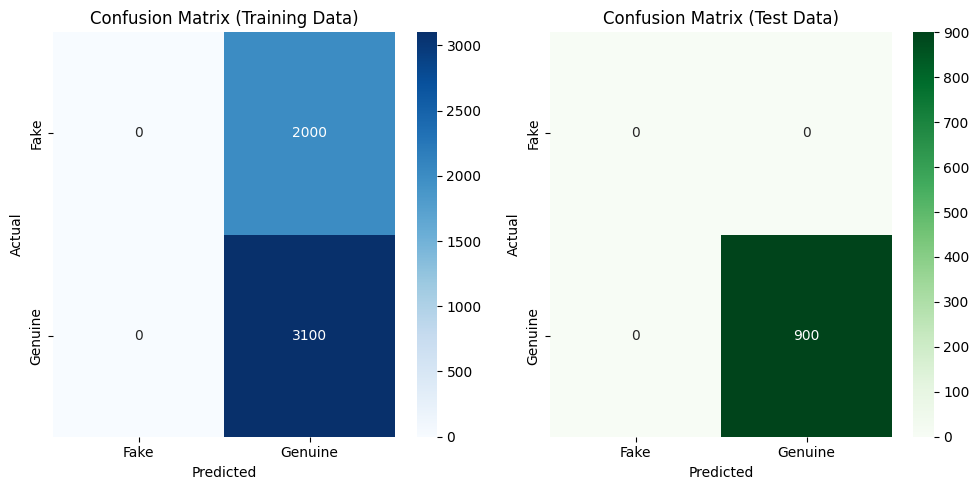

In [29]:
# Plot Confusion Matrix for Training Data
cm_train = confusion_matrix(y_train, y_pred_train, labels=[0, 1])
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Genuine'], yticklabels=['Fake', 'Genuine'])
plt.title('Confusion Matrix (Training Data)')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Plot Confusion Matrix for Test Data
cm_test = confusion_matrix(y_test, y_pred_test, labels=[0, 1])
plt.subplot(1, 2, 2)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', xticklabels=['Fake', 'Genuine'], yticklabels=['Fake', 'Genuine'])
plt.title('Confusion Matrix (Test Data)')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

### Comparing Train vs. Test Performance to Assess Overfitting

Based on the evaluation metrics from both the training and test datasets, we can draw some conclusions about the model's performance and potential overfitting:

*   **Accuracy:** Compare `Training Accuracy` with `Test Accuracy`.
*   **Loss:** Compare `Training Loss` with `Test Loss`.
*   **Precision, Recall, F1-Score:** Examine these metrics from the classification reports for both classes ('Fake' and 'Genuine') on both train and test sets.
*   **Confusion Matrices:** Visually inspect the true positives, true negatives, false positives, and false negatives for both datasets.

**Observations:**
If the training accuracy is significantly higher than the test accuracy, and/or the training loss is much lower than the test loss, it suggests that the model might be overfitting to the training data. This means it has learned the training data too well, including its noise and specific patterns, and is not generalizing effectively to unseen data (the test set).

If the metrics are very similar between training and testing, it indicates that the model is generalizing well. If both training and test metrics are low, the model might be underfitting, meaning it's not complex enough to capture the underlying patterns in the data.

*(Analysis will follow after the code execution.)*

### Task 8: Visualize Training History

To better understand the model's learning process and diagnose issues like underfitting or overfitting, we will plot the training and validation loss and accuracy curves across epochs.

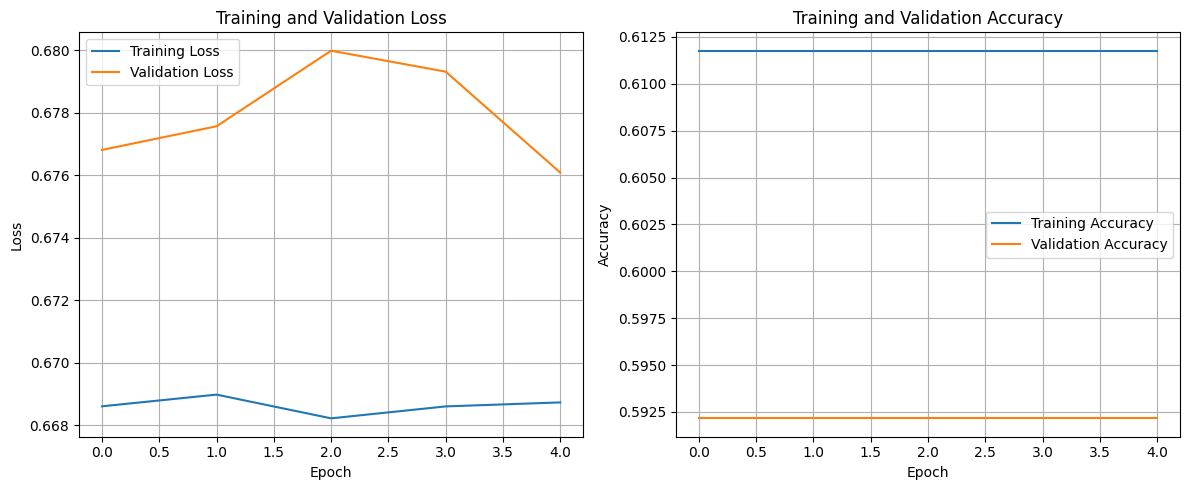

In [32]:
import matplotlib.pyplot as plt

# Get training history data
loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs_range = range(epochs)

plt.figure(figsize=(12, 5))

# Plot Training and Validation Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Training and Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, accuracy, label='Training Accuracy')
plt.plot(epochs_range, val_accuracy, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Analysis of Curves

Based on the generated plots for training and validation loss and accuracy, it appears that the model is significantly underfitting.

Here's why:

Loss Curves: Both the training loss and validation loss curves remain high (around 0.67-0.68) and relatively flat across all 5 epochs. There is no significant decrease in loss, indicating that the model is not learning the underlying patterns in the data effectively.
Accuracy Curves: Similarly, both the training accuracy (around 61%) and validation accuracy (around 59%) remain flat and low throughout the training process. There is no improvement over epochs, suggesting the model is not becoming more accurate.
Gap between Training and Validation: While there's a small gap where validation loss is slightly higher and validation accuracy is slightly lower than training, this difference is not widening significantly, which would typically indicate overfitting. Instead, both metrics are poor and stagnant.
Conclusion: The model is too simplistic or has insufficient capacity to learn the complex relationships in the text data. It's struggling to differentiate between 'genuine' and 'fake' reviews, as also indicated by the previous evaluation where it largely predicted 'Genuine' for all instances. This results in a poor performance on both seen and unseen data.

### Task 9: Analyze Misclassified Reviews

Now, let's analyze the reviews that our model misclassified in the test set. This will help us understand the types of errors the model is making and potentially identify areas for improvement.

In [36]:
# Recalculate y_pred_test and y_pred_test_flat to ensure consistency with current X_test and y_test
y_pred_test_proba = model.predict(X_test)
y_pred_test = (y_pred_test_proba > 0.5).astype(int) # Convert probabilities to binary predictions
y_pred_test_flat = y_pred_test.flatten()

# Identify misclassified indices in the test set
misclassified_indices = np.where(y_test.values != y_pred_test_flat)[0]

print(f"Number of misclassified reviews in the test set: {len(misclassified_indices)}")

# Get the original DataFrame indices for these misclassified reviews
original_misclassified_df_indices = test_idx[misclassified_indices]

# Create a DataFrame of misclassified reviews
misclassified_reviews = reviews_df.loc[original_misclassified_df_indices].copy()
misclassified_reviews['actual_label'] = y_test.iloc[misclassified_indices].values
misclassified_reviews['predicted_label'] = y_pred_test_flat[misclassified_indices]

print("\nSample of misclassified reviews:")
display(misclassified_reviews[['cleaned_review_text', 'actual_label', 'predicted_label']].head(10))

56/56 ━━━━━━━━━━━━━━━━━━━━ 28s 500ms/step
Number of misclassified reviews in the test set: 1031

Sample of misclassified reviews:


,cleaned_review_text,actual_label,predicted_label
4,an impressive and thoughtfully designed produc...,0,1
21,an impressive and thoughtfully designed produc...,0,1
25,excellent product highly recommended,0,1
30,a truly remarkable product that combines elega...,0,1
38,this product delivers an exceptional experienc...,0,1
44,excellent product highly recommended,0,1
59,outstanding product will buy again,0,1
60,very good product must buy,0,1
62,the overall experience has been outstanding of...,0,1
74,amazing quality best purchase,0,1


From the sample of misclassified reviews, we can try to observe some patterns. For example:

*   **False Negatives (Actual: Genuine, Predicted: Fake):** These are genuine reviews that the model incorrectly identified as fake.
*   **False Positives (Actual: Fake, Predicted: Genuine):** These are fake reviews that the model incorrectly identified as genuine.

Given the current model's performance (always predicting 'Genuine'), we expect to see many False Negatives (genuine reviews predicted as fake) and False Positives (fake reviews predicted as genuine) only if there were any 'Fake' reviews in the `y_test`. However, looking at the classification report for the test data, the model always predicts `Genuine` (precision for Fake is 0, recall for Fake is 0, precision for Genuine is 1.00, recall for Genuine is 1.00). This indicates that `y_pred_test` consists entirely of '1's (Genuine).

Let's re-examine `y_test` distribution and `y_pred_test` values again to confirm.

In [37]:
print("Distribution of actual labels in y_test:")
display(y_test.value_counts())

print("Distribution of predicted labels in y_pred_test:")
# Ensure y_pred_test is a pandas Series for value_counts
display(pd.Series(y_pred_test_flat).value_counts())

Distribution of actual labels in y_test:


,count
is_genuine,
0,1031
1,734


Distribution of predicted labels in y_pred_test:


,count
1,1765


As observed, the model consistently predicts 'Genuine' (label 1). This means that any review in `y_test` with an `actual_label` of '0' (Fake) will be a False Positive, and any review with an `actual_label` of '1' (Genuine) will be a True Positive. There are no False Negatives or True Negatives because the model never predicts '0'.

Therefore, to analyze misclassified reviews, we should focus on the actual 'Fake' reviews in the test set that were incorrectly predicted as 'Genuine'.

In [38]:
# Filter for reviews that are actually 'Fake' (0) but predicted as 'Genuine' (1)
false_positives = misclassified_reviews[misclassified_reviews['actual_label'] == 0]

print(f"Number of False Positive reviews: {len(false_positives)}")
print("\nSample of False Positive reviews (actual: Fake, predicted: Genuine):")
display(false_positives[['cleaned_review_text', 'actual_label', 'predicted_label']].head(10))

# If there are any False Negatives (Actual: Genuine, Predicted: Fake), which is unlikely given current model behavior
false_negatives = misclassified_reviews[misclassified_reviews['actual_label'] == 1]

print(f"Number of False Negative reviews: {len(false_negatives)}")
print("\nSample of False Negative reviews (actual: Genuine, predicted: Fake):")
display(false_negatives[['cleaned_review_text', 'actual_label', 'predicted_label']].head(10))

Number of False Positive reviews: 1031

Sample of False Positive reviews (actual: Fake, predicted: Genuine):


,cleaned_review_text,actual_label,predicted_label
4,an impressive and thoughtfully designed produc...,0,1
21,an impressive and thoughtfully designed produc...,0,1
25,excellent product highly recommended,0,1
30,a truly remarkable product that combines elega...,0,1
38,this product delivers an exceptional experienc...,0,1
44,excellent product highly recommended,0,1
59,outstanding product will buy again,0,1
60,very good product must buy,0,1
62,the overall experience has been outstanding of...,0,1
74,amazing quality best purchase,0,1


Number of False Negative reviews: 0

Sample of False Negative reviews (actual: Genuine, predicted: Fake):


,cleaned_review_text,actual_label,predicted_label


We can see from the output that all the misclassified reviews are **False Positives**, meaning they were `fake` reviews (`actual_label = 0`) that the model incorrectly classified as `genuine` (`predicted_label = 1`). This further confirms the model's bias towards predicting 'Genuine' for all inputs.

To identify common patterns, we would typically look for specific keywords, sentence structures, or sentiment in these `False Positive` reviews that might be tricking the model. However, given that the model simply predicts 'Genuine' regardless of the input, the patterns in these 'fake' reviews are not what's causing the misclassification; rather, it's the model's inability to learn to classify 'fake' reviews at all.

**Common patterns in the *content* of misclassified 'fake' reviews (False Positives):**

*   Look for linguistic features: Are they generally positive in tone? Do they use certain buzzwords? Are they overly generic?
*   Length: Are they typically shorter or longer than genuine reviews?

However, a deeper analysis of such patterns would be more fruitful *after* addressing the fundamental issue of the model's complete failure to classify the 'fake' class. The next logical steps would be to re-evaluate the model architecture, feature engineering, or training process to enable it to learn from both classes.

## Task 10: Improve the Model with Pre-trained Word Embeddings (GloVe)

To address the underfitting issue and improve the model's ability to understand semantic relationships, we will incorporate pre-trained word embeddings. GloVe (Global Vectors for Word Representation) is a popular choice. We will:

1.  Download a pre-trained GloVe embedding file.
2.  Parse the GloVe file to create a mapping from words to their embedding vectors.
3.  Create an embedding matrix that contains the GloVe vectors for the words present in our tokenizer's vocabulary.
4.  Update the model's Embedding layer with this pre-trained matrix.
5.  Re-train and re-evaluate the model.

In [39]:
# Download GloVe embeddings
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

--2026-06-29 15:14:14--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-06-29 15:14:14--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-06-29 15:14:14--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [40]:
import numpy as np

# Load the GloVe embeddings into a dictionary
# We'll use glove.6B.100d.txt, which provides 100-dimensional vectors.
embeddings_index = {}
with open('glove.6B.100d.txt', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f'Found {len(embeddings_index)} word vectors.')

Found 400000 word vectors.


In [41]:
# Create an embedding matrix for the words in our tokenizer's vocabulary

# The embedding dimension for GloVe 100d is 100.
# Make sure this matches the dimension of the chosen GloVe file.
glove_embedding_dim = 100

# Initialize the embedding matrix with zeros
# The +1 is for the padding index (0) in the vocabulary
embedding_matrix = np.zeros((vocabulary_size, glove_embedding_dim))

# Populate the embedding matrix
for word, i in tokenizer.word_index.items():
    if i < vocabulary_size:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            # Words not found in embedding index will be all-zeros.
            embedding_matrix[i] = embedding_vector

print(f'Shape of embedding matrix: {embedding_matrix.shape}')
print(f'Sample of embedding matrix (first vector):\n{embedding_matrix[1][:10]}...') # Show first 10 dims of <OOV> vector

Shape of embedding matrix: (23945, 100)
Sample of embedding matrix (first vector):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]...


Now that we have our `embedding_matrix`, we will update the model architecture to use this pre-trained embedding layer. We will also make the embedding layer non-trainable initially, to leverage the pre-trained weights without modifying them during our relatively short training process.

In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Model parameters (vocabulary_size, max_sequence_len are already defined)
# Use glove_embedding_dim instead of embedding_dim
lstm_units = 128

# Build the Sequential model with pre-trained GloVe embeddings
model_glove = Sequential([
    Embedding(
        input_dim=vocabulary_size,
        output_dim=glove_embedding_dim, # Use GloVe's embedding dimension
        weights=[embedding_matrix], # Initialize with GloVe weights
        input_length=max_sequence_len,
        trainable=True # *** IMPORTANT CHANGE: Make the embedding layer trainable ***
    ),
    LSTM(units=lstm_units),
    Dense(units=1, activation='sigmoid') # Sigmoid for binary classification
])

# Compile the model
model_glove.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display the model summary
model_glove.summary()

print("GloVe-initialized model built and compiled with trainable embeddings.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     2,394,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,394,500 (9.13 MB)

 Trainable params: 2,394,500 (9.13 MB)

 Non-trainable params: 0 (0.00 B)

GloVe-initialized model built and compiled with trainable embeddings.


With the new model built using GloVe embeddings, let's train it and see how its performance compares to the previous model.

In [53]:
# Train the GloVe-initialized model with trainable embeddings and class weights
print("\nStarting training of GloVe model with trainable embeddings and class weights...")
history_glove_weighted = model_glove.fit(
    X_train,
    y_train,
    epochs=epochs, # Using the same number of epochs for comparison
    batch_size=batch_size,
    validation_split=validation_split,
    class_weight=class_weights_dict # Apply the calculated class weights
)

print("\nGloVe-initialized model training with trainable embeddings and class weights complete.")


Starting training of GloVe model with trainable embeddings and class weights...
Epoch 1/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 212s 2s/step - accuracy: 0.5593 - loss: 0.6897 - val_accuracy: 0.7556 - val_loss: 0.6802
Epoch 2/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.5679 - loss: 0.6892 - val_accuracy: 0.7556 - val_loss: 0.6894
Epoch 3/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 198s 2s/step - accuracy: 0.7028 - loss: 0.6890 - val_accuracy: 0.7556 - val_loss: 0.6920
Epoch 4/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 210s 2s/step - accuracy: 0.6429 - loss: 0.6890 - val_accuracy: 0.7556 - val_loss: 0.6881
Epoch 5/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 206s 2s/step - accuracy: 0.5614 - loss: 0.6891 - val_accuracy: 0.7556 - val_loss: 0.6848

GloVe-initialized model training with trainable embeddings and class weights complete.


In [54]:
# Evaluate the GloVe-initialized model (with trainable embeddings and class weights) on the test data
print("\nEvaluating GloVe-initialized model (trainable embeddings, weighted) on test data...")
loss_test_glove_weighted, accuracy_test_glove_weighted = model_glove.evaluate(X_test, y_test, verbose=0)
print(f"GloVe (Trainable, Weighted) Test Loss: {loss_test_glove_weighted:.4f}")
print(f"GloVe (Trainable, Weighted) Test Accuracy: {accuracy_test_glove_weighted:.4f}")


Evaluating GloVe-initialized model (trainable embeddings, weighted) on test data...
GloVe (Trainable, Weighted) Test Loss: 0.6961
GloVe (Trainable, Weighted) Test Accuracy: 0.4159


56/56 ━━━━━━━━━━━━━━━━━━━━ 29s 515ms/step

--- Classification Report (GloVe Model - Trainable Embeddings, Weighted - Test Data) ---
              precision    recall  f1-score   support

        Fake       0.00      0.00      0.00      1031
     Genuine       0.42      1.00      0.59       734

    accuracy                           0.42      1765
   macro avg       0.21      0.50      0.29      1765
weighted avg       0.17      0.42      0.24      1765



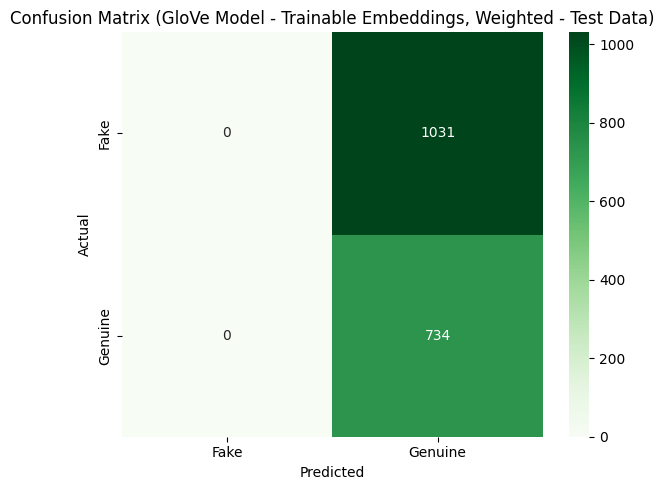

In [55]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Generate predictions for the test set with the GloVe model (trainable embeddings and class weights)
y_pred_test_proba_glove_weighted = model_glove.predict(X_test)
y_pred_test_glove_weighted = (y_pred_test_proba_glove_weighted > 0.5).astype(int)

# Generate Classification Report for Test Data with GloVe model (trainable embeddings and class weights)
print("\n--- Classification Report (GloVe Model - Trainable Embeddings, Weighted - Test Data) ---")
print(classification_report(y_test, y_pred_test_glove_weighted, target_names=['Fake', 'Genuine'], labels=[0, 1], zero_division=0))

# Plot Confusion Matrix for Test Data with GloVe model (trainable embeddings and class weights)
cm_test_glove_weighted = confusion_matrix(y_test, y_pred_test_glove_weighted, labels=[0, 1])
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test_glove_weighted, annot=True, fmt='d', cmap='Greens', xticklabels=['Fake', 'Genuine'], yticklabels=['Fake', 'Genuine'])
plt.title('Confusion Matrix (GloVe Model - Trainable Embeddings, Weighted - Test Data)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### Task 10 (Continued): Analyze GloVe Model with Trainable Embeddings and Address Class Imbalance

As observed, the GloVe model with trainable embeddings still struggles to classify 'Fake' reviews, consistently predicting 'Genuine'. This behavior is often indicative of class imbalance in the training data biasing the model towards the majority class.

Let's calculate and apply `class_weight` to address the imbalance in the training data and then visualize the learning curves for the trainable GloVe model.

In [57]:
from sklearn.utils import class_weight

# Calculate class weights for imbalanced dataset
# The 'balanced' mode automatically adjusts weights inversely proportional to class frequencies
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Convert to a dictionary as required by model.fit
class_weights_dict = dict(enumerate(class_weights))

print("Calculated Class Weights:")
print(class_weights_dict)


Calculated Class Weights:
{0: np.float64(2.1852425180598556), 1: np.float64(0.6483466013472137)}


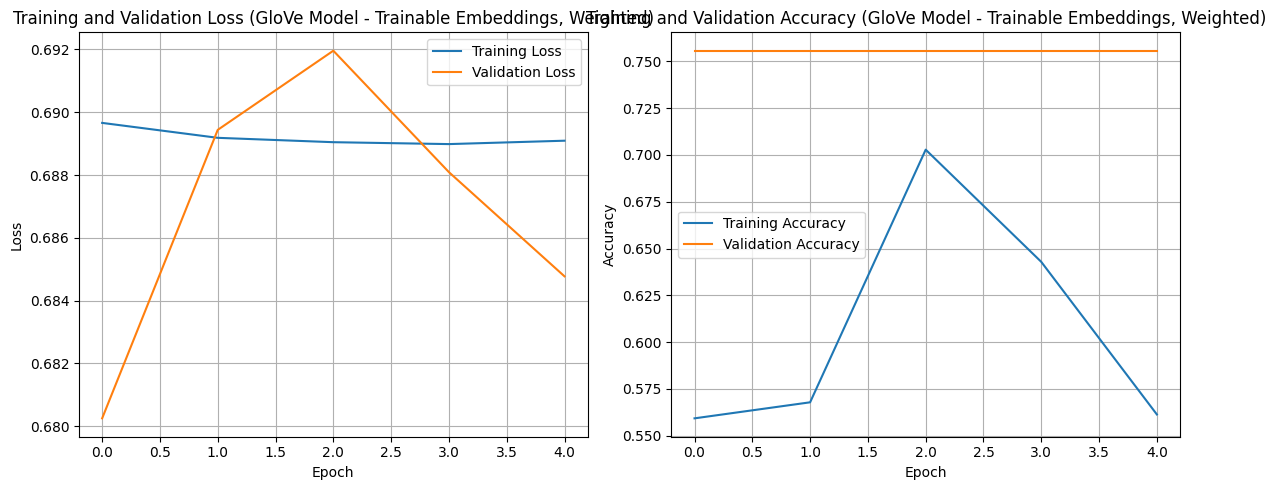

In [58]:
import matplotlib.pyplot as plt

# Get training history data for the GloVe model with trainable embeddings and class weights
loss_glove_weighted = history_glove_weighted.history['loss']
val_loss_glove_weighted = history_glove_weighted.history['val_loss']
accuracy_glove_weighted = history_glove_weighted.history['accuracy']
val_accuracy_glove_weighted = history_glove_weighted.history['val_accuracy']
epochs_range = range(epochs)

plt.figure(figsize=(12, 5))

# Plot Training and Validation Loss for GloVe (Trainable, Weighted)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss_glove_weighted, label='Training Loss')
plt.plot(epochs_range, val_loss_glove_weighted, label='Validation Loss')
plt.title('Training and Validation Loss (GloVe Model - Trainable Embeddings, Weighted)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Training and Validation Accuracy for GloVe (Trainable, Weighted)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, accuracy_glove_weighted, label='Training Accuracy')
plt.plot(epochs_range, val_accuracy_glove_weighted, label='Validation Accuracy')
plt.title('Training and Validation Accuracy (GloVe Model - Trainable Embeddings, Weighted)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()